In [ ]:
#IMPORTING OF LIBRARIES

# utilities
import re
import numpy as np
import pandas as pd
import nltk
import tweepy
from textblob import TextBlob
from wordcloud import WordCloud

# plotting
import seaborn as sns
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# nltk
import nltk
# utilities


# nltk
from nltk.stem import WordNetLemmatizer



In [ ]:
#importing dataset
DATASET_COLUMNS = ['Tweets']
DATASET_ENCODING = 'ISO-8859-1'
df = pd.read_csv('/content/iyke.csv' , encoding = DATASET_ENCODING, names = DATASET_COLUMNS )
df.head()

,Tweets
0,Tweets
1,The most useless network I have ever seen is ...
2,Jeeez \n@TelecelGhana\n \nYour network is so b...
3,omg nobody should advice themselves to get fib...
4,This network....hmmm \n@TelecelGhana


In [ ]:
#columns in data

df.columns


Index(['Tweets'], dtype='object')

In [ ]:
df.dtypes

,0
Tweets,object


In [ ]:
df['Tweets'].unique()

array(['Tweets',
       'The most useless network I have  ever seen is \n@TelecelGhana\n mtcheeew',
       "Jeeez \n@TelecelGhana\n \nYour network is so bad I can't even use the data I bought with my own money. It's even crazier when 4G is boldly displayed. Might have to switch back to MTN cos this is just horrendous. I don't even believe that upload speed. Do better.",
       'omg nobody should advice themselves to get fiber broadband from \n@TelecelGhana\n ! It\x92s a nightmare i promise . had someone sold me i would have never',
       'This network....hmmm \n@TelecelGhana',
       "But seriously, \n@TelecelGhana\n our expectations of you were low, but this is the lowest of lows. \nYou can't even connect calls, talmbout connecting energies??",
       'Does \n@TelecelGhana\n actually pay attention to the numerous complaints from its customers about the network?\nAs a responsible company, you should at least acknowledge these issues and communicate with the people who pay for your ser

In [ ]:
df.head()


,Tweets
0,Tweets
1,The most useless network I have ever seen is ...
2,Jeeez \n@TelecelGhana\n \nYour network is so b...
3,omg nobody should advice themselves to get fib...
4,This network....hmmm \n@TelecelGhana


In [ ]:
df.tail()

,Tweets
994,Bro see how Telecel disgraced you for network ...
995,ei @TelecelGhana\n pls why have you withdrawn ...
996,The most useless network in Ghana \n@TelecelGh...
997,"The weekend is back, and Telecel Ghana is savi..."
998,"Telecel, you people are the wackest network in..."


In [ ]:
#MAKING TWEETS LOWER CASE


df['Tweets'] =df['Tweets'].str.lower()
df['Tweets'].tail()


,Tweets
994,bro see how telecel disgraced you for network ...
995,ei @telecelghana\n pls why have you withdrawn ...
996,the most useless network in ghana \n@telecelgh...
997,"the weekend is back, and telecel ghana is savi..."
998,"telecel, you people are the wackest network in..."


In [ ]:
#defining list of stopwords
stopwordlist = ['a', 'about', 'above', 'after', 'again', 'ain', 'all', 'am', 'an',
             'and','any','are', 'as', 'at', 'be', 'because', 'been', 'before',
             'being', 'below', 'between','both', 'by', 'can', 'd', 'did', 'do',
             'does', 'doing', 'down', 'during', 'each','few', 'for', 'from',
             'further', 'had', 'has', 'have', 'having', 'he', 'her', 'here',
             'hers', 'herself', 'him', 'himself', 'his', 'how', 'i', 'if', 'in',
             'into','is', 'it', 'its', 'itself', 'just', 'll', 'm', 'ma',
             'me', 'more', 'most','my', 'myself', 'now', 'o', 'of', 'on', 'once',
             'only', 'or', 'other', 'our', 'ours','ourselves', 'out', 'own', 're','s', 'same', 'she', "shes", 'should', "shouldve",'so', 'some', 'such',
             't', 'than', 'that', "thatll", 'the', 'their', 'theirs','the', 'that', 'them',
             'themselves', 'then', 'there', 'these', 'they', 'this', 'those',
             'through', 'to', 'too','under', 'until', 'up', 've', 'very', 'was',
             'we', 'were', 'what', 'when', 'where','which','while', 'who', 'whom',
             'why', 'will', 'with', 'won', 'y', 'you', "youd","youll", "youre",
             "youve", 'your', 'yours', 'yourself', 'yourselves','']

In [ ]:
#REMOVING STOPWORDS

STOPWORDS = set(stopwordlist)
def cleaning_stopwords(text):
    return " ".join([word for word in str(text).split() if word not in STOPWORDS])
df['Tweets'] = df['Tweets'].apply(lambda text: cleaning_stopwords(text))
df['Tweets'].head()

,Tweets
0,tweets
1,useless network ever seen @telecelghana mtcheeew
2,jeeez @telecelghana network bad can't even use...
3,omg nobody advice get fiber broadband @telecel...
4,network....hmmm @telecelghana


In [ ]:
df.tail()

,Tweets
994,bro see telecel disgraced network ein matter ?...
995,ei @telecelghana pls withdrawn money telecel c...
996,useless network ghana @telecelghana use telece...
997,"weekend back, telecel ghana saving day bossu w..."
998,"telecel, people wackest network ghana telecel ..."


In [ ]:
#REMOVING OF PUNCTUATIONS

import string
english_punctuations = string.punctuation
punctuations_list = english_punctuations
def cleaning_punctuations(text):
    translator = str.maketrans('', '', punctuations_list)
    return text.translate(translator)
df['Tweets']= df['Tweets'].apply(lambda x: cleaning_punctuations(x))
df['Tweets'].head()
df['Tweets'].tail()

,Tweets
994,bro see telecel disgraced network ein matter
995,ei telecelghana pls withdrawn money telecel ca...
996,useless network ghana telecelghana use telecel...
997,weekend back telecel ghana saving day bossu we...
998,telecel people wackest network ghana telecel n...


In [ ]:
#CLEANING AND REMOVING REPEATING CHARACTERS

def cleaning_repeating_char(text):
    return re.sub(r'(.)1+', r'1', text)
df['Tweets'] = df['Tweets'].apply(lambda x: cleaning_repeating_char(x))
df['Tweets'].tail()


,Tweets
994,bro see telecel disgraced network ein matter
995,ei telecelghana pls withdrawn money telecel ca...
996,useless network ghana telecelghana use telecel...
997,weekend back telecel ghana saving day bossu we...
998,telecel people wackest network ghana telecel n...


In [ ]:
#CLEANING AND REMOVING URL'S

def cleaning_URLs(data):
    return re.sub('((www.[^s]+)|(https?://[^s]+))',' ',data)
df['Tweets'] = df['Tweets'].apply(lambda x: cleaning_URLs(x))
df['Tweets'].head()
df['Tweets'].tail()

,Tweets
994,bro see telecel disgraced network ein matter
995,ei telecelghana pls withdrawn money telecel ca...
996,useless network ghana telecelghana use telecel...
997,weekend back telecel ghana saving day bossu we...
998,telecel people wackest network ghana telecel n...


In [ ]:
#REMOVING NUMERIC NUMBERS

def cleaning_numbers(data):
    return re.sub('[0-9]+', '', data)
df['Tweets'] = df['Tweets'].apply(lambda x: cleaning_numbers(x))
df['Tweets'].head()
df['Tweets'].tail()

,Tweets
994,bro see telecel disgraced network ein matter
995,ei telecelghana pls withdrawn money telecel ca...
996,useless network ghana telecelghana use telecel...
997,weekend back telecel ghana saving day bossu we...
998,telecel people wackest network ghana telecel n...


In [ ]:
#applying stemming

import nltk
st = nltk.PorterStemmer()
def stemming_on_text(data):
    text = [st.stem(word) for word in data]
    return data
df['Tweets']= df['Tweets'].apply(lambda x: stemming_on_text(x))
df['Tweets'].head()
df['Tweets'].tail()

,Tweets
994,bro see telecel disgraced network ein matter
995,ei telecelghana pls withdrawn money telecel ca...
996,useless network ghana telecelghana use telecel...
997,weekend back telecel ghana saving day bossu we...
998,telecel people wackest network ghana telecel n...


In [ ]:
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
#APPLYING LEMMITIZATION


lm = nltk.WordNetLemmatizer()
def lemmatizer_on_text(data):
    text = [lm.lemmatize(word) for word in data]
    return data
df['Tweets'] = df['Tweets'].apply(lambda x: lemmatizer_on_text(x))
df['Tweets'].tail()




,Tweets
994,bro see telecel disgraced network ein matter
995,ei telecelghana pls withdrawn money telecel ca...
996,useless network ghana telecelghana use telecel...
997,weekend back telecel ghana saving day bossu we...
998,telecel people wackest network ghana telecel n...


In [ ]:

#Creating a function to get the subjectivity

def getSubjectivity(text):
    return TextBlob(text).sentiment.subjectivity

#Create a function to get Polarity

def getPolarity(text):
    return TextBlob(text).sentiment.polarity


#Create two new columns
df['Subjectivity'] =df['Tweets'].apply(getSubjectivity)
df['Polarity'] = df['Tweets'].apply(getPolarity)


#show the new dataframe with the new columns with Polarity and Subjectivity
df



,Tweets,Subjectivity,Polarity
0,tweets,0.000000,0.000000
1,useless network ever seen telecelghana mtcheeew,0.200000,-0.500000
2,jeeez telecelghana network bad cant even use d...,0.458333,0.033333
3,omg nobody advice get fiber broadband telecelg...,0.000000,0.000000
4,networkhmmm telecelghana,0.000000,0.000000
...,...,...,...
994,bro see telecel disgraced network ein matter,0.000000,0.000000
995,ei telecelghana pls withdrawn money telecel ca...,0.000000,0.000000
996,useless network ghana telecelghana use telecel...,0.300000,-0.400000
997,weekend back telecel ghana saving day bossu we...,0.412500,0.187500


In [ ]:
#Create a function to compute the negativity and positivity

def getAnalysis(score):
    if score < 0:
        return 'Negativity'
    elif score == 0:
        return 'Neutral'
    else:
        return 'Positive'

df['Analysis'] = df['Polarity'].apply(getAnalysis)


#Showing Dataframe to verify results

df


,Tweets,Subjectivity,Polarity,Analysis
0,tweets,0.000000,0.000000,Neutral
1,useless network ever seen telecelghana mtcheeew,0.200000,-0.500000,Negativity
2,jeeez telecelghana network bad cant even use d...,0.458333,0.033333,Positive
3,omg nobody advice get fiber broadband telecelg...,0.000000,0.000000,Neutral
4,networkhmmm telecelghana,0.000000,0.000000,Neutral
...,...,...,...,...
994,bro see telecel disgraced network ein matter,0.000000,0.000000,Neutral
995,ei telecelghana pls withdrawn money telecel ca...,0.000000,0.000000,Neutral
996,useless network ghana telecelghana use telecel...,0.300000,-0.400000,Negativity
997,weekend back telecel ghana saving day bossu we...,0.412500,0.187500,Positive


In [ ]:
# Save the processed DataFrame to a CSV file
df.to_csv('processed_data.csv', index=False)

print("Processed data saved to 'processed_data.csv'")

Processed data saved to 'processed_data.csv'


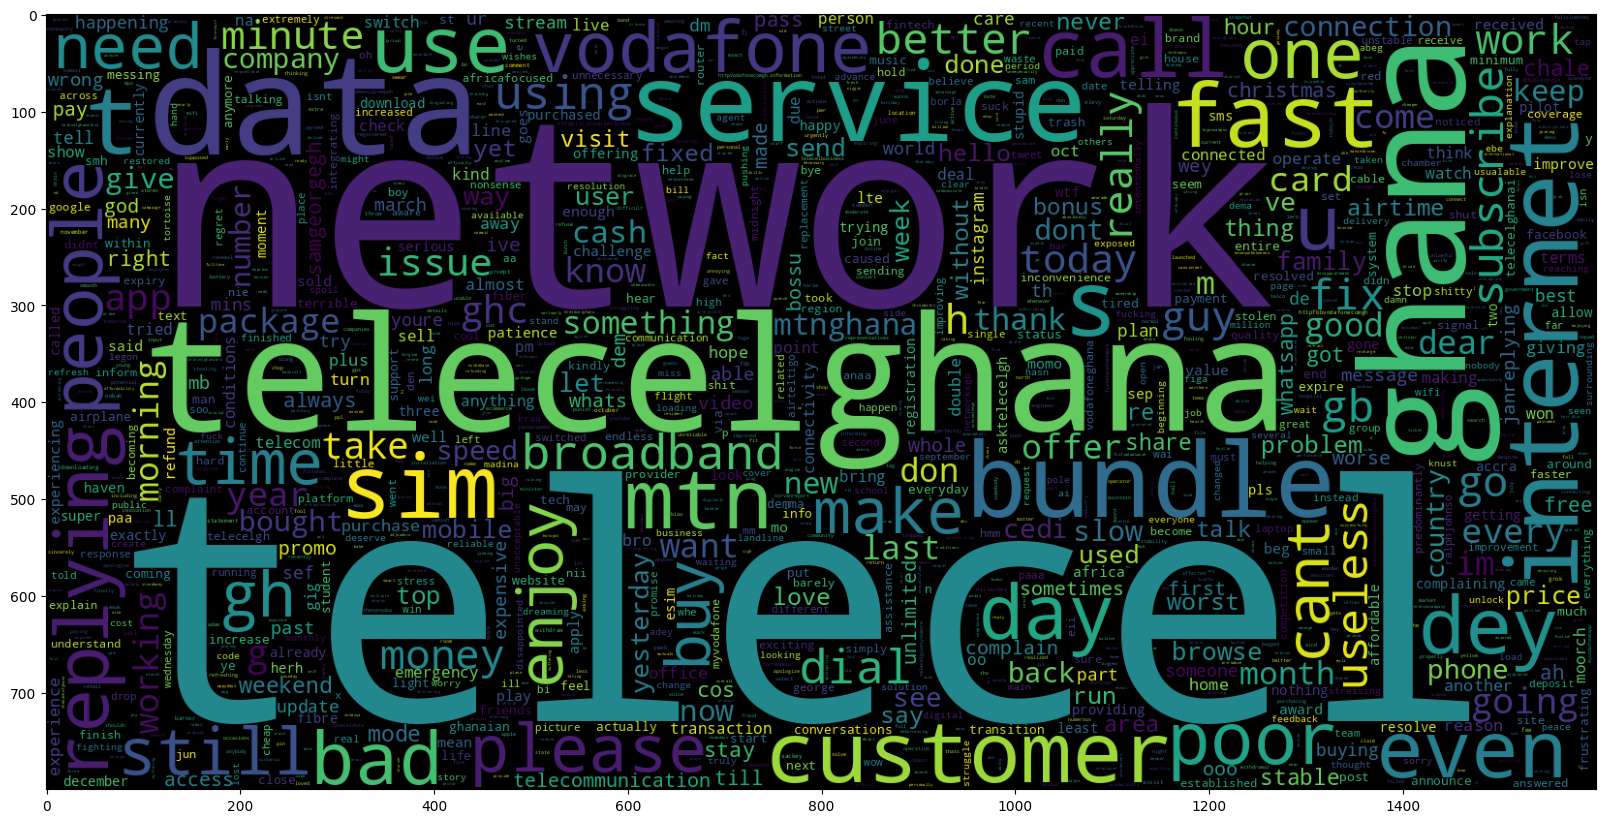

In [ ]:
 #plotting of wordcloud

data_neg = df['Tweets'][:800000]
plt.figure(figsize = (20,20))
wc = WordCloud(max_words = 20000 , width = 1600 , height = 800,
               collocations=False).generate(" ".join(data_neg))
plt.imshow(wc)

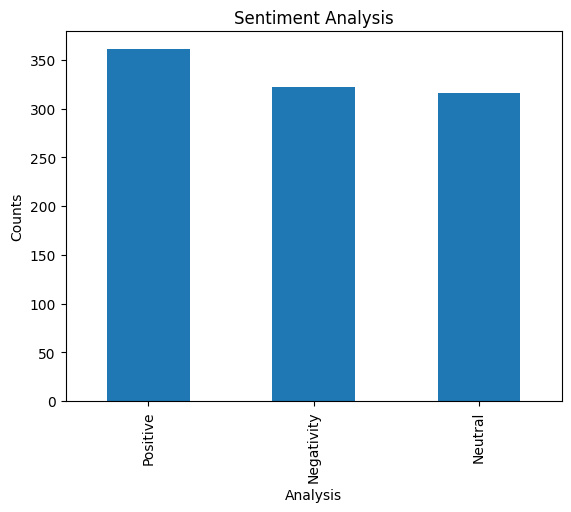

In [ ]:
#showing plot for value counts

df['Analysis'].value_counts()

#plot and visualizing counts

plt.title('Sentiment Analysis')
plt.xlabel('Sentiment')
plt.ylabel('Counts')
df['Analysis'].value_counts().plot(kind='bar')
plt.show()

In [ ]:
import matplotlib.pyplot as plt

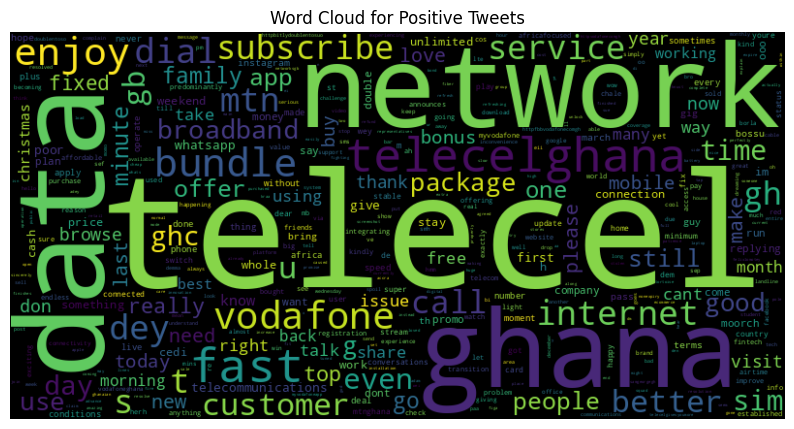

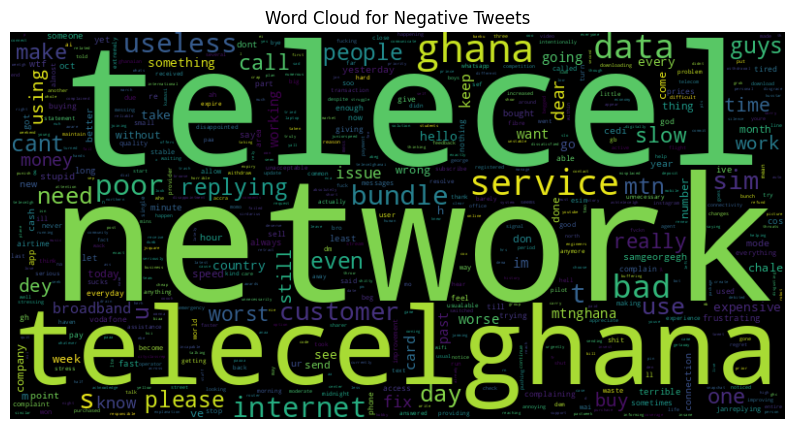

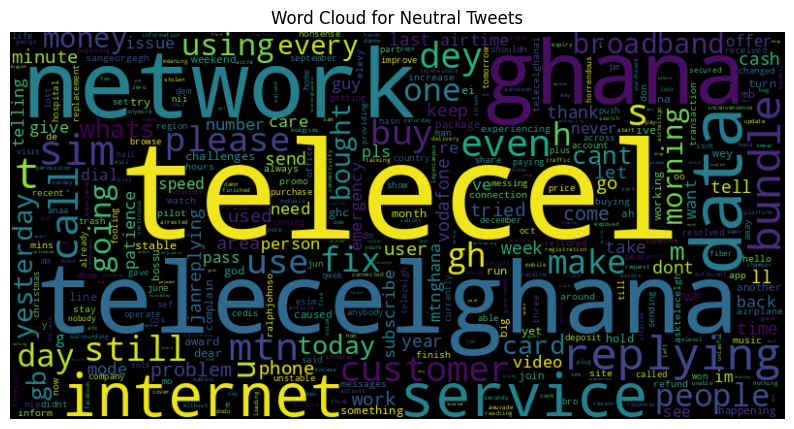

In [ ]:
# Separate tweets by sentiment
positive_tweets = df[df['Analysis'] == 'Positive']['Tweets']
negative_tweets = df[df['Analysis'] == 'Negativity']['Tweets']
neutral_tweets = df[df['Analysis'] == 'Neutral']['Tweets']

# Generate and display word cloud for Positive tweets
plt.figure(figsize = (10, 10))
positive_wc = WordCloud(max_words = 2000 , width = 800 , height = 400,
                         collocations=False).generate(" ".join(positive_tweets))
plt.imshow(positive_wc, interpolation='bilinear')
plt.axis("off")
plt.title('Word Cloud for Positive Tweets')
plt.show()

# Generate and display word cloud for Negative tweets
plt.figure(figsize = (10, 10))
negative_wc = WordCloud(max_words = 2000 , width = 800 , height = 400,
                         collocations=False).generate(" ".join(negative_tweets))
plt.imshow(negative_wc, interpolation='bilinear')
plt.axis("off")
plt.title('Word Cloud for Negative Tweets')
plt.show()

# Generate and display word cloud for Neutral tweets
plt.figure(figsize = (10, 10))
neutral_wc = WordCloud(max_words = 2000 , width = 800 , height = 400,
                        collocations=False).generate(" ".join(neutral_tweets))
plt.imshow(neutral_wc, interpolation='bilinear')
plt.axis("off")
plt.title('Word Cloud for Neutral Tweets')
plt.show()

In [ ]:
import nltk
nltk.download('punkt_tab')



[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')

# Tokenize tweets for each sentiment
positive_words = word_tokenize(" ".join(positive_tweets))
negative_words = word_tokenize(" ".join(negative_tweets))
neutral_words = word_tokenize(" ".join(neutral_tweets))

# Calculate frequency distribution for each sentiment
positive_freq = nltk.FreqDist(positive_words)
negative_freq = nltk.FreqDist(negative_words)
neutral_freq = nltk.FreqDist(neutral_words)

# Display the most common words for each sentiment
print("Most common words in Positive Tweets:")
display(positive_freq.most_common(10))

print("\nMost common words in Negative Tweets:")
display(negative_freq.most_common(10))

print("\nMost common words in Neutral Tweets:")
display(neutral_freq.most_common(10))

Most common words in Positive Tweets:


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


[('telecel', 251),
 ('data', 139),
 ('network', 103),
 ('ghana', 97),
 ('telecelghana', 82),
 ('fast', 82),
 ('enjoy', 51),
 ('vodafone', 44),
 ('dial', 40),
 ('dey', 38)]


Most common words in Negative Tweets:


[('network', 212),
 ('telecel', 200),
 ('telecelghana', 158),
 ('ghana', 89),
 ('data', 67),
 ('service', 62),
 ('bad', 60),
 ('poor', 50),
 ('not', 49),
 ('internet', 46)]


Most common words in Neutral Tweets:


[('telecel', 217),
 ('telecelghana', 99),
 ('network', 90),
 ('ghana', 79),
 ('data', 50),
 ('internet', 34),
 ('no', 31),
 ('replying', 30),
 ('sim', 26),
 ('bundle', 24)]

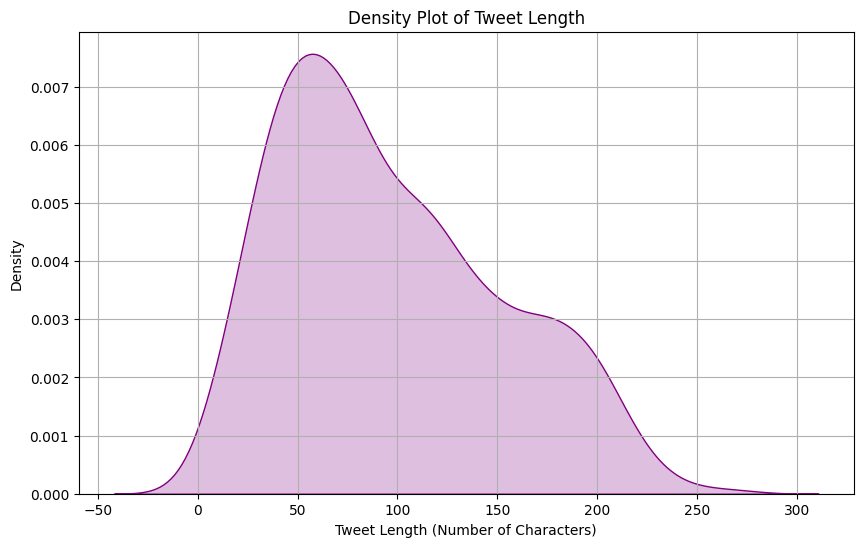

In [ ]:
df['Tweet_Length'] = df['Tweets'].apply(len)

plt.figure(figsize=(10, 6))
sns.kdeplot(df['Tweet_Length'], fill=True, color='purple')
plt.title('Density Plot of Tweet Length')
plt.xlabel('Tweet Length (Number of Characters)')
plt.ylabel('Density')
plt.grid(True)
plt.show()